## Customer Segmentation Project

- Mall Customers dataset 
- we will implement K means clustering to check the spending patterns of our customers
- segment the customer spending behaviour


Task:
1. data ingestion/acquisition
2. Data EDA
3. Preprocessing, if needed
4. train a model 
5. Cluster the users 

Optional
6. Tag each cluter with a name and save that column in dataframe

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [60]:
##Data Cleaning bcs have non numerical column and remove the id bcs its sequential
#use one hot encoding

df_cleaned = df.drop(columns=['CustomerID'])
df_encoded = pd.get_dummies(df_cleaned, columns=['Gender'], dtype=int)
df_encoded

#scale
from scipy.stats import zscore

df_scaled = df_encoded.apply(zscore)
df_scaled

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405
...,...,...,...,...,...
195,-0.276302,2.268791,1.118061,0.886405,-0.886405
196,0.441365,2.497807,-0.861839,0.886405,-0.886405
197,-0.491602,2.497807,0.923953,-1.128152,1.128152
198,-0.491602,2.917671,-1.250054,-1.128152,1.128152


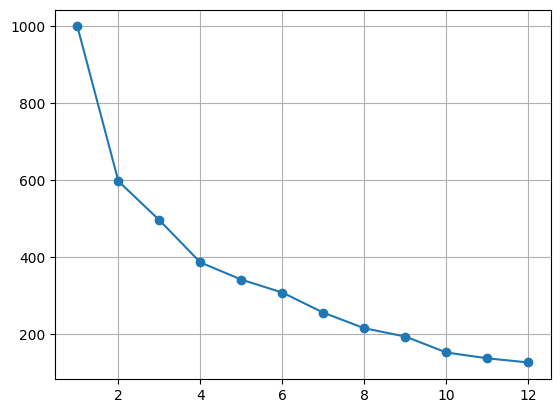

In [61]:
# Elbow Method

errors = []

for k in range(1, 13):
    kmeans = KMeans(n_clusters = k, random_state= 42)
    kmeans.fit(df_scaled)
    errors.append(kmeans.inertia_)

plt.plot(range(1,13), errors, marker = 'o')
plt.grid()
plt.show()

In [62]:
model_kmeans = KMeans(
    n_clusters = 5, # based on elbow
    init = 'random',
    random_state = 42
)

model_kmeans

,n_clusters,5
,init,'random'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [63]:
df_scaled['KClustering'] = model_kmeans.fit_predict(df_scaled)
df_scaled

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,KClustering
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152,1
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152,1
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405,4
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405,4
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405,4
...,...,...,...,...,...,...
195,-0.276302,2.268791,1.118061,0.886405,-0.886405,0
196,0.441365,2.497807,-0.861839,0.886405,-0.886405,3
197,-0.491602,2.497807,0.923953,-1.128152,1.128152,1
198,-0.491602,2.917671,-1.250054,-1.128152,1.128152,2


In [64]:
df_scaled['Annual Income (k$)'].min()

np.float64(-1.7389991930659485)

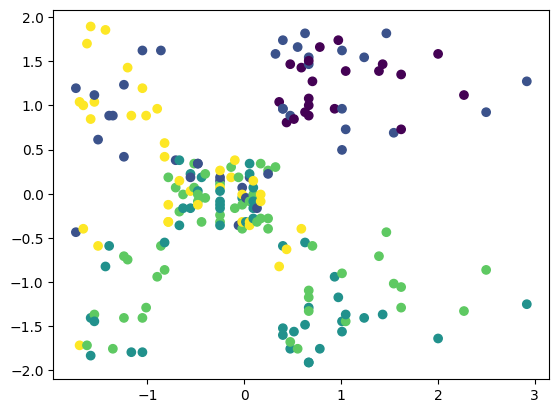

In [65]:
plt.scatter(df_scaled['Annual Income (k$)'],df_scaled['Spending Score (1-100)'], c = df_scaled['KClustering'])
plt.show()

In [66]:
cluster_names = {
    0: "Normal",
    1: "High Income, High Spending",
    2: "Low Income, High Spending",
    3: "High Income, Low Spending",
    4: "Low Income, Low Spending"
}

df_scaled["Customer Type"] = df_scaled["KClustering"].map(cluster_names)
df_scaled.sample(7)

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,KClustering,Customer Type
38,-0.204535,-0.899272,-0.939482,0.886405,-0.886405,3,"High Income, Low Spending"
134,-1.352802,0.474828,-1.754735,-1.128152,1.128152,2,"Low Income, High Spending"
56,0.871965,-0.632086,-0.007764,0.886405,-0.886405,3,"High Income, Low Spending"
198,-0.491602,2.917671,-1.250054,-1.128152,1.128152,2,"Low Income, High Spending"
6,-0.276302,-1.624491,-1.715913,0.886405,-0.886405,3,"High Income, Low Spending"
55,0.584899,-0.670255,-0.357158,-1.128152,1.128152,2,"Low Income, High Spending"
127,0.082532,0.398489,1.739206,-1.128152,1.128152,1,"High Income, High Spending"
